In [1]:
import os
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch
from transformers import (
AutoTokenizer,
AutoModelForSequenceClassification,
TrainingArguments,
Trainer,
DataCollatorWithPadding,
)
from datasets import Dataset, DatasetDict

In [2]:
seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.mps.is_available():
    torch.mps.manual_seed(seed)

In [3]:
MODEL_NAME = 'bert-base-uncased' # change to 'distilbert-base-uncased' if you need smaller model
MAX_LEN = 256
BATCH_SIZE = 16
EPOCHS = 2
LEARNING_RATE = 2e-5
output_dir = './bert_imdb_checkpoints'

In [4]:
os.makedirs(output_dir, exist_ok=True)
print('PyTorch device:', torch.device('cuda' if torch.cuda.is_available() else "mps" if torch.mps.is_available()  else 'cpu'))

PyTorch device: mps


In [5]:
DATA_PATH = 'IMDB Dataset.csv' # path to file downloaded from Kaggle
assert os.path.exists(DATA_PATH), f"Dataset file not found at {DATA_PATH}. Download and place the CSV in working dir."

In [6]:
df = pd.read_csv(DATA_PATH)
print(df.shape)

(50000, 2)


In [7]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [8]:
print(df.sentiment.value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [9]:
sentiment_map = {'positive': 1, 'negative': 0}
df['label_id'] = df.sentiment.map(sentiment_map)

In [10]:
df.head()

,review,sentiment,label_id
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


In [11]:
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label_id'], random_state=seed)

In [12]:
train_df, val_df = train_test_split(train_df, test_size=0.1, stratify=train_df['label_id'], random_state=seed)

In [13]:
print('Train:', len(train_df), 'Val:', len(val_df), 'Test:', len(test_df))

Train: 36000 Val: 4000 Test: 10000


In [14]:
raw_datasets = DatasetDict({
    'train': Dataset.from_pandas(train_df.reset_index(drop=True)),
    'validation': Dataset.from_pandas(val_df.reset_index(drop=True)),
    'test': Dataset.from_pandas(test_df.reset_index(drop=True)),
})

In [15]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['review', 'sentiment', 'label_id'],
        num_rows: 36000
    })
    validation: Dataset({
        features: ['review', 'sentiment', 'label_id'],
        num_rows: 4000
    })
    test: Dataset({
        features: ['review', 'sentiment', 'label_id'],
        num_rows: 10000
    })
})

In [16]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [17]:
def tokenize_batch(batch):
    return tokenizer(
    batch['review'],
    padding=False, # we'll use DataCollatorWithPadding later
    truncation=True,
    max_length=MAX_LEN,
    )

In [18]:
tokenized_datasets = raw_datasets.map(tokenize_batch, batched=True, remove_columns=['review', 'sentiment'])

Map:   0%|          | 0/36000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [19]:
for split in tokenized_datasets:
    tokenized_datasets[split] = tokenized_datasets[split].rename_column('label_id', 'labels')

In [20]:
tokenized_datasets.set_format('torch')

In [22]:
num_labels = 2
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.config.id2label = {0: 'negative', 1: 'positive'}
model.config.label2id = {'negative': 0, 'positive': 1}

In [24]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [25]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [26]:
training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    logging_strategy='steps',
    logging_steps=200,
    save_total_limit=3,
    fp16=torch.cuda.is_available(),
    bf16=True,
    seed=seed,
)

In [27]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

/var/folders/d9/34q0n1js31x765w00t009x6c0000gn/T/ipykernel_3959/3348431065.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [28]:
trainer.train()

/Users/chyavanshenoy/Desktop/Uni/AAI-520/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.224800,0.200956,0.925500,0.922542,0.929000,0.925760
2,0.156400,0.247570,0.927500,0.917480,0.939500,0.928360


/Users/chyavanshenoy/Desktop/Uni/AAI-520/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=4500, training_loss=0.19891872957017687, metrics={'train_runtime': 1597.8853, 'train_samples_per_second': 45.06, 'train_steps_per_second': 2.816, 'total_flos': 9471956881857600.0, 'train_loss': 0.19891872957017687, 'epoch': 2.0})

In [29]:
trainer.save_model(os.path.join(output_dir, 'final-model'))
tokenizer.save_pretrained(os.path.join(output_dir, 'final-model'))

('./bert_imdb_checkpoints/final-model/tokenizer_config.json',
 './bert_imdb_checkpoints/final-model/special_tokens_map.json',
 './bert_imdb_checkpoints/final-model/vocab.txt',
 './bert_imdb_checkpoints/final-model/added_tokens.json',
 './bert_imdb_checkpoints/final-model/tokenizer.json')

In [30]:
metrics = trainer.evaluate(tokenized_datasets['test'])
print(metrics)

/Users/chyavanshenoy/Desktop/Uni/AAI-520/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.24761167168617249, 'eval_accuracy': 0.9304, 'eval_precision': 0.9242902208201893, 'eval_recall': 0.9376, 'eval_f1': 0.9308975377283558, 'eval_runtime': 61.1181, 'eval_samples_per_second': 163.618, 'eval_steps_per_second': 10.226, 'epoch': 2.0}


In [31]:
preds_output = trainer.predict(tokenized_datasets['test'])
logits = preds_output.predictions
preds = np.argmax(logits, axis=-1)
labels = preds_output.label_ids

/Users/chyavanshenoy/Desktop/Uni/AAI-520/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [32]:
acc = accuracy_score(labels, preds)
precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')

In [33]:
from sklearn.metrics import classification_report
print('Accuracy:', acc)
print('Precision:', precision)
print('Recall:', recall)
print('F1:', f1)

Accuracy: 0.9304
Precision: 0.9242902208201893
Recall: 0.9376
F1: 0.9308975377283558


In [34]:
print('\nClassification Report:')
print(classification_report(labels, preds, target_names=['negative', 'positive']))


Classification Report:
              precision    recall  f1-score   support

    negative       0.94      0.92      0.93      5000
    positive       0.92      0.94      0.93      5000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [35]:
pipeline_inputs = [
"I absolutely loved this movie. The plot was gripping and the acting was top-notch.",
"This was the worst film I have seen in years. Boring and predictable.",
"Mediocre story but decent cinematography. Not bad, not great.",
]

In [36]:
enc = tokenizer(pipeline_inputs, truncation=True, padding=True, return_tensors='pt', max_length=MAX_LEN)
enc = {k: v.to(trainer.args.device) for k, v in enc.items()}

In [37]:
with torch.no_grad():
    out = model(**enc)
    probs = torch.softmax(out.logits, dim=-1).cpu().numpy()
    pred_labels = np.argmax(probs, axis=-1)

In [38]:
for text, pl, p in zip(pipeline_inputs, pred_labels, probs):
    print('REVIEW:', text)
    print('PRED:', model.config.id2label[int(pl)], ' — probs:', p)
    print('---')

REVIEW: I absolutely loved this movie. The plot was gripping and the acting was top-notch.
PRED: positive  — probs: [0.00282995 0.99717003]
---
REVIEW: This was the worst film I have seen in years. Boring and predictable.
PRED: negative  — probs: [0.9987324  0.00126758]
---
REVIEW: Mediocre story but decent cinematography. Not bad, not great.
PRED: negative  — probs: [0.9919233  0.00807673]
---


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [44]:
cm = confusion_matrix(labels, preds)
class_names = ['negative', 'positive']

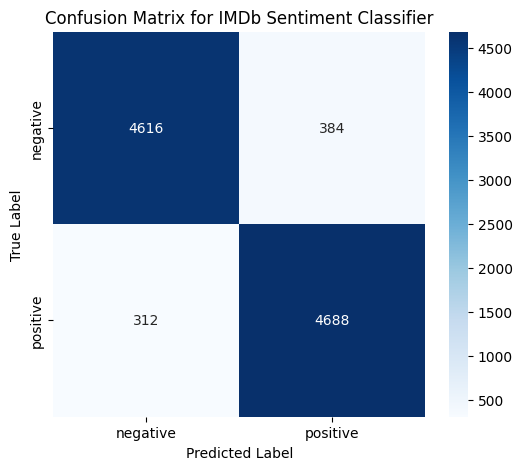

In [45]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)

plt.title("Confusion Matrix for IMDb Sentiment Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Observations

### Model Performance


- The fine-tuned `bert-base-uncased` model achieved 93.04% accuracy on the IMDb test set.
- Precision (0.92) and recall (0.94) are well balanced, which means the model is both `accurate in its positive predictions` (precision) and `captures most actual positives` (recall).
- The `F1-score of 0.93` confirms the model’s strong balance between precision and recall, making it reliable for binary sentiment classification.

### Confusion Matrix Insights

- The confusion matrix shows the following breakdown on `10,000 test reviews`:
    - `4616 true negatives` (correctly predicted as negative)
    - `4688 true positives` (correctly predicted as positive).
    - `384 false positives` (negative reviews misclassified as positive).
    - `312 false negatives` (positive reviews misclassified as negative).
- Errors are relatively balanced between classes, indicating no major bias toward either sentiment.
- The low misclassification numbers further support the robustness of the model.

### Class-Level Observations

- Both `negative` and `positive` classes achieved high F1-scores (~0.93 each).
- This balance suggests that the stratified split worked as intended and that BERT fine-tuning was successful in learning sentiment features.

### Qualitative Predictions

- For strongly worded reviews, the model performs with very high confidence (e.g., “I absolutely loved this movie” → positive, 99.7%).
- For nuanced or mixed reviews (e.g., “Mediocre story but decent cinematography”), the model `defaults to negative`. This shows that `binary sentiment analysis is limited when handling reviews` that are not strictly positive or negative.

### Limitations

- **Binary Setup**: The model cannot handle neutral/mixed reviews well, as IMDb labels only provide positive or negative classes.
- **Ambiguity & Sarcasm**: Irony, sarcasm, or highly nuanced opinions may be misclassified because BERT focuses on token-level context rather than deeper intent.
- **Training Configuration**: Only 2 epochs were used. While this prevented overfitting, additional epochs, hyperparameter tuning, or learning rate scheduling might yield slightly higher scores.

### Future Improvements

- **Introduce Neutral Class**: Expanding to a three-class setup (positive, neutral, negative) would allow the model to capture mixed sentiments.
- **Error Analysis**: Examining reviews from the misclassified set could reveal common failure cases (e.g., sarcasm-heavy reviews).
- **Explainability**: Applying tools like LIME or SHAP could highlight which words most influenced predictions, making the model more interpretable.
- **Model Variants**: Exploring DistilBERT for faster inference or RoBERTa for potentially higher accuracy could provide practical trade-offs.
- **Visualization**: Including metrics plots (e.g., training loss curves) would give additional insight into model convergence and generalization.

### Overall Interpretation

- The fine-tuned BERT model demonstrates excellent performance on binary sentiment classification, achieving over 93% accuracy.
- Results are consistent across classes, with minimal misclassification bias.
- While highly effective, the model’s limitations become clear in borderline or nuanced reviews, pointing to the need for neutral sentiment classification or multi-label approaches in real-world applications.